## Filter Methods:
Selecting features based on statistical tests, independent of any machine learning model.

## Filter Methods: Chi-Square Test:

Chi-Square ($\chi^2$) Test for Feature Selection:
This method is used for categorical features in a classification task. It tests the independence between a feature and the target class.

* **Null Hypothesis ($H_0$):** The feature and the target are independent (unrelated).
* **Alternate Hypothesis ($H_1$):** The feature and the target are dependent (related).

We want features with a **high Chi-Square score** (and low p-value), meaning they are highly dependent on the target and thus informative.

$$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$
Where $O$ is Observed frequency and $E$ is Expected frequency.

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

#### 2) Loading Data:

In [2]:
data = load_iris()
X, y = data.data, data.target

In [5]:
# Adding some noisy random features to test the selection:

np.random.seed(42)
noise = np.random.randint(0, 10, size=(X.shape[0], 4)) # 4 random features

In [7]:
# Attaching Noise to X:
X_noisy = np.hstack([X, noise])

In [8]:
X_noisy

array([[5.1, 3.5, 1.4, ..., 3. , 7. , 4. ],
       [4.9, 3. , 1.4, ..., 9. , 2. , 6. ],
       [4.7, 3.2, 1.3, ..., 4. , 3. , 7. ],
       ...,
       [6.5, 3. , 5.2, ..., 4. , 4. , 3. ],
       [6.2, 3.4, 5.4, ..., 2. , 3. , 8. ],
       [5.9, 3. , 5.1, ..., 8. , 0. , 0. ]], shape=(150, 8))

#### 3) Scaling:

In [9]:
X_scaled = MinMaxScaler().fit_transform(X_noisy)

In [10]:
# Train Test Split:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

#### 4) Chi-Square Selection:

In [11]:
# Selecting top 2 features (Original Iris has 4 good ones, we added 4 bad ones):

chi2_selector = SelectKBest(chi2, k= 2)
X_train_kbest = chi2_selector.fit_transform(X_train, y_train)
X_test_kbest = chi2_selector.transform(X_test)

#### 5) Comparing Models with and without Feature Selection:

In [12]:
model_all = LogisticRegression(max_iter=1000).fit(X_train, y_train)
acc_all = model_all.score(X_test, y_test)

In [13]:
model_chi = LogisticRegression(max_iter=1000).fit(X_train_kbest, y_train)
acc_chi = model_chi.score(X_test_kbest, y_test)

In [14]:
print(f"Accuracy with all features (inc. noise): {acc_all:.4f}")
print(f"Accuracy with Chi-Square Top 2: {acc_chi:.4f}")

Accuracy with all features (inc. noise): 0.9333
Accuracy with Chi-Square Top 2: 0.9778


#### 6) Visualization of Scores by Chi2:

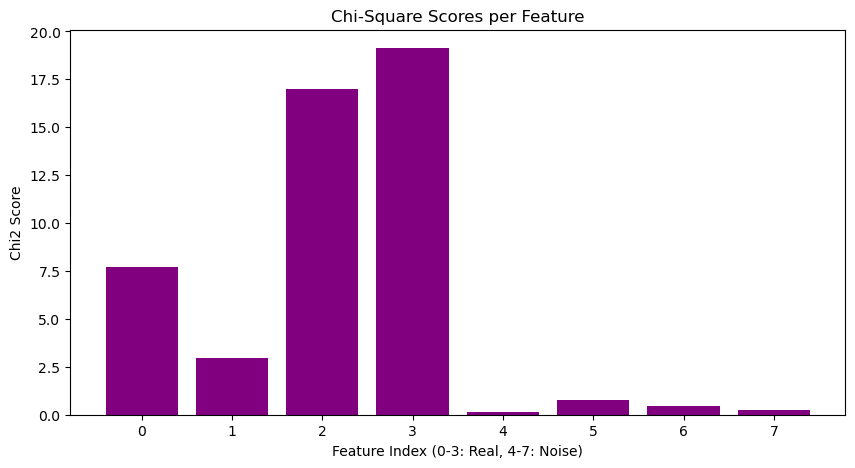

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(range(X_train.shape[1]), chi2_selector.scores_, color='purple')
plt.title("Chi-Square Scores per Feature")
plt.xlabel("Feature Index (0-3: Real, 4-7: Noise)")
plt.ylabel("Chi2 Score")
plt.show()